In [10]:
import importlib
import torch
from models.condition_methods import get_condition_method
from models.measurements import get_operator,get_noise
from utils import get_logger
import numpy as np
import matplotlib.pyplot as plt

In [11]:
configs = importlib.import_module(f"configs.ve.fastmri_knee_720_ncsnpp_continuous")
config = configs.get_config()
device=config.device
logger = get_logger()
logger.info(f"Device set to {device}.")

2024-12-02 15:52:24,056 [DPS] >> Device set to cuda:0.
2024-12-02 15:52:24,056 [DPS] >> Device set to cuda:0.
2024-12-02 15:52:24,056 [DPS] >> Device set to cuda:0.


In [12]:
#Prepare Operator and noise
measure_config = config.measurement
operator=get_operator(device=device, **measure_config.operator)
noiser = get_noise(**measure_config.noise)
logger.info(f"Operation: {measure_config.operator.name} / Noise: {measure_config.noise.name}")

# Prepare conditioning method
cond_config = config.conditioning
cond_method = get_condition_method(cond_config.method, operator, noiser, **cond_config.params)

2024-12-02 15:52:24,297 [DPS] >> Operation: Kernel / Noise: gaussian
2024-12-02 15:52:24,297 [DPS] >> Operation: Kernel / Noise: gaussian
2024-12-02 15:52:24,297 [DPS] >> Operation: Kernel / Noise: gaussian


loaded checkpoint dir from /home/cidar/Desktop/MRI_superres_registration/Kernel_Learning/workdir/checkpoints-meta/checkpoint.pth


In [13]:
hr_image=np.load('/home/cidar/Desktop/MRI_superres_registration/test/HR/AD_F11_90_AD_F11_90_slice_40.npy').astype(np.float32)
lr_image=np.load('/home/cidar/Desktop/MRI_superres_registration/test/LR/AD_F11_90_AD_F11_90_slice_40.npy').astype(np.float32)

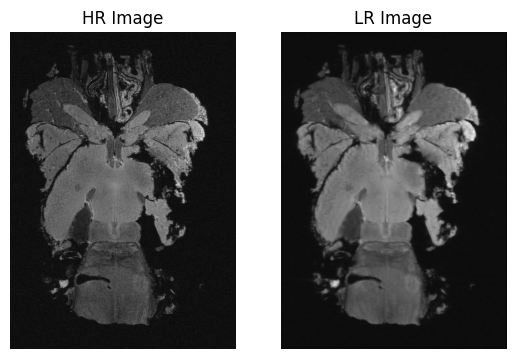

In [14]:
plt.subplot(1,2,1)
plt.imshow(hr_image,cmap='gray')
plt.title('HR Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(lr_image,cmap='gray')
plt.title('LR Image')
plt.axis('off')
plt.show()

In [16]:
hr_tensor=torch.from_numpy(hr_image).unsqueeze(0).unsqueeze(0).to(torch.device('cuda'))
lr_pred=operator.forward(hr_tensor)

In [17]:
lr_pred=lr_pred.squeeze(0).squeeze(0).detach().cpu().numpy()

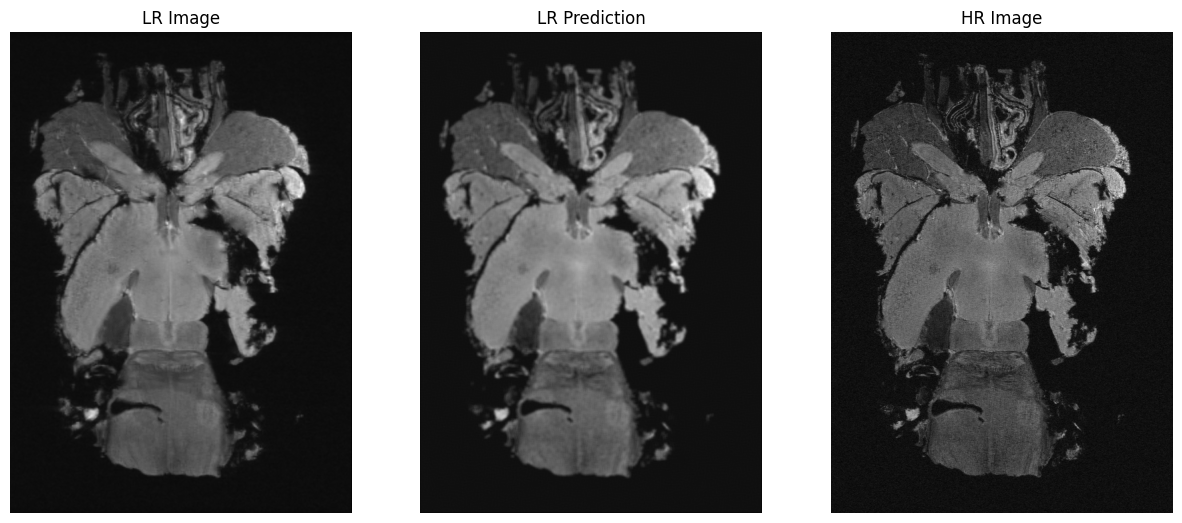

In [18]:
plt.figure(figsize=(15,15))
plt.subplot(1,3,1)
plt.imshow(lr_image,cmap='gray')
plt.title('LR Image')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(lr_pred,cmap='gray')
plt.title('LR Prediction')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(hr_image,cmap='gray')
plt.title('HR Image')
plt.axis('off')
plt.show()